In [68]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

import yaml
from ultralytics import YOLO
from src.model_utils import smart_predict,export_enum_by_quad_using_model
from src.generate_report import generate_report
import pandas as pd

%matplotlib inline

In [ ]:
with open('../configs/stage1.yaml','r') as f:

    stage1_config = yaml.safe_load(f)


with open('../configs/stage2.yaml','r') as f:

    stage2_config = yaml.safe_load(f)


with open(stage1_config['model_args']['data'],'r') as f:

    quad_data_yaml = yaml.safe_load(f)

In [86]:
stage1_config

{'paths': {'original_images_path': '../Data/Raw/DENTEX CHALLENGE 2023/Training_data/quadrant/xrays',
  'original_json_path': '../Data/Raw/DENTEX CHALLENGE 2023/Training_data/quadrant/train_quadrant.json',
  's1_main_path': '..\\Data\\Processed\\Stage 1 (Quadrant Detection)',
  'runs_s1_output': '..\\Runs\\Stage 1'},
 'model_args': {'data': '..\\Data\\Processed\\Stage 1 (Quadrant Detection)\\data.yaml',
  'model': '../Models/yolo26s.pt',
  'epochs': 50,
  'save': True,
  'imgsz': 1024,
  'batch': 8,
  'patience': 10,
  'optimizer': 'AdamW',
  'lr0': 0.001,
  'lrf': 0.001,
  'plots': True,
  'verbose': True,
  'device': 'cuda',
  'workers': 4,
  'project': 'Runs',
  'name': 'Stage 1',
  'save_dir': '..\\Runs\\Stage 1',
  'auto_augment': 'None',
  'augment': False,
  'mosaic': 0.0,
  'mixup': 0.0,
  'copy_paste': 0.0,
  'cutmix': 0.0,
  'hsv_h': 0.0,
  'hsv_s': 0.0,
  'hsv_v': 0.0,
  'degrees': 0.0,
  'translate': 0.0,
  'scale': 0.0,
  'shear': 0.0,
  'perspective': 0.0,
  'flipud': 0.0,

In [80]:
stage2_config

{'paths': {'original_images_path': '../Data/Raw/DENTEX CHALLENGE 2023/Training_data/quadrant-enumeration/xrays',
  'original_json_path': '../Data/Raw/DENTEX CHALLENGE 2023/Training_data/quadrant-enumeration/train_quadrant_enumeration.json',
  's2_main_path': '..\\Data\\Processed\\Stage 2 (Enumeration Detection)',
  'runs_s2_output': '..\\Runs\\Stage 2'},
 'model_args': {'data': '..\\Data\\Processed\\Stage 2 (Enumeration Detection)\\data.yaml'}}

In [81]:
quad_data_yaml

{'train': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 1 (Quadrant Detection)\\train\\images',
 'val': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 1 (Quadrant Detection)\\valid\\images',
 'test': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 1 (Quadrant Detection)\\test\\images',
 'nc': 4,
 'names': ['Upper Right', 'Upper Left', 'Lower Left', 'Lower Right']}

In [83]:
yolo_model = YOLO(stage1_config['model_args']['model'])

In [ ]:
yolo_model.train(**stage1_config['model_args'])

New https://pypi.org/project/ultralytics/8.4.103 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.83  Python-3.13.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\Data\Processed\Stage 1 (Quadrant Detection)\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.0, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=../Models/yolo26s.pt, m

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001FF36C8E900>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
       

In [ ]:
quadrant_model_detection = YOLO(os.path.join(stage1_config['paths']['runs_s1_output'], 'weights', 'last.pt'))


image 1/1 c:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Notebooks\..\Data\Raw\DENTEX CHALLENGE 2023\Training_Data\quadrant-enumeration-disease\xrays\train_619.png: 480x1024 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 12.5ms
Speed: 3.6ms preprocess, 12.5ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 1024)
Class Name: Lower Left
Coordinates: [1415.503173828125, 627.7108764648438, 2242.53564453125, 1126.4984130859375]
Confidence: %99.0
Class Name: Upper Right
Coordinates: [721.6641845703125, 451.2322692871094, 1406.2635498046875, 789.50439453125]
Confidence: %99.0
Class Name: Upper Left
Coordinates: [1400.6990966796875, 431.1456604003906, 2205.843505859375, 773.4165649414062]
Confidence: %90.0
Class Name: Lower Right
Coordinates: [646.0208129882812, 715.8765258789062, 1439.3125, 1123.173095703125]
Confidence: %42.0


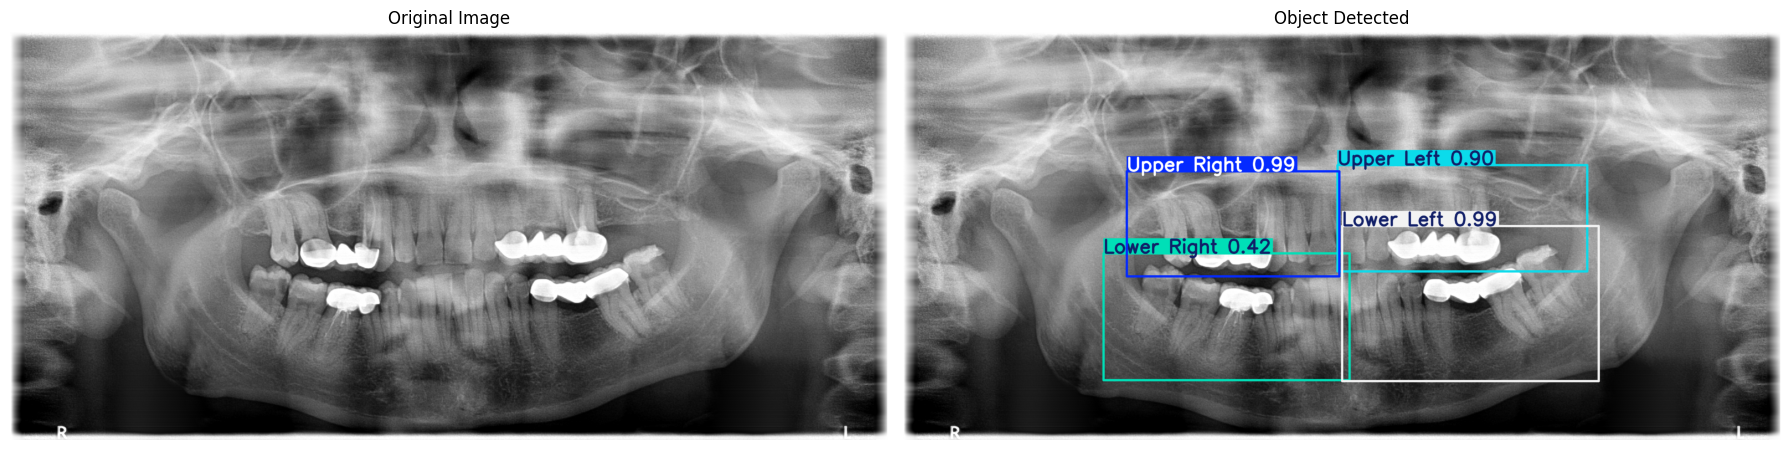

In [ ]:
smart_predict(quadrant_model_detection,quad_data_yaml['test'])


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_284.png: 480x1024 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 97.1ms
Speed: 14.3ms preprocess, 97.1ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 1024)
Class Name: Upper Left
Coordinates: [1485.734375, 302.140625, 2095.41357421875, 736.197998046875]
Confidence: %99.0
Class Name: Upper Right
Coordinates: [868.2702026367188, 333.8301696777344, 1499.2813720703125, 745.1804809570312]
Confidence: %99.0
Class Name: Lower Right
Coordinates: [770.37548828125, 606.5411987304688, 1521.9359130859375, 1098.299072265625]
Confidence: %99.0
Class Name: Lower Left
Coordinates: [1480.9169921875, 575.22314453125, 2227.69775390625, 1089.81103515625]
Confidence: %98.0


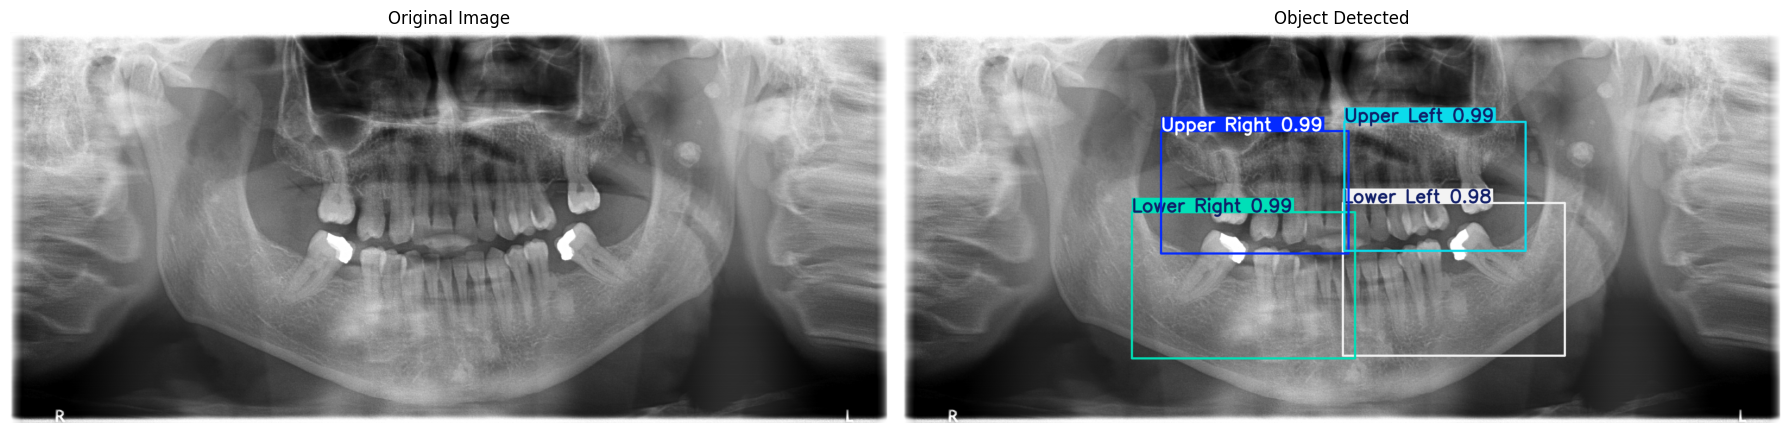

In [ ]:
smart_predict(quadrant_model_detection,quad_data_yaml['test'],save_output=True,save_dir=os.path.join(stage1_config['paths']['runs_s1_output'],'Test Outputs Predictions'))


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_241.png: 512x1024 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 89.8ms
Speed: 5.4ms preprocess, 89.8ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 1024)
Class Name: Lower Left
Coordinates: [1379.4638671875, 573.2013549804688, 2201.747802734375, 1074.2203369140625]
Confidence: %99.0
Class Name: Upper Right
Coordinates: [627.5994873046875, 267.8916931152344, 1382.2191162109375, 672.7194213867188]
Confidence: %99.0
Class Name: Upper Left
Coordinates: [1380.779296875, 255.97640991210938, 2154.52685546875, 675.162353515625]
Confidence: %99.0
Class Name: Lower Right
Coordinates: [569.7120361328125, 573.7730102539062, 1392.9342041015625, 1073.19921875]
Confidence: %98.0


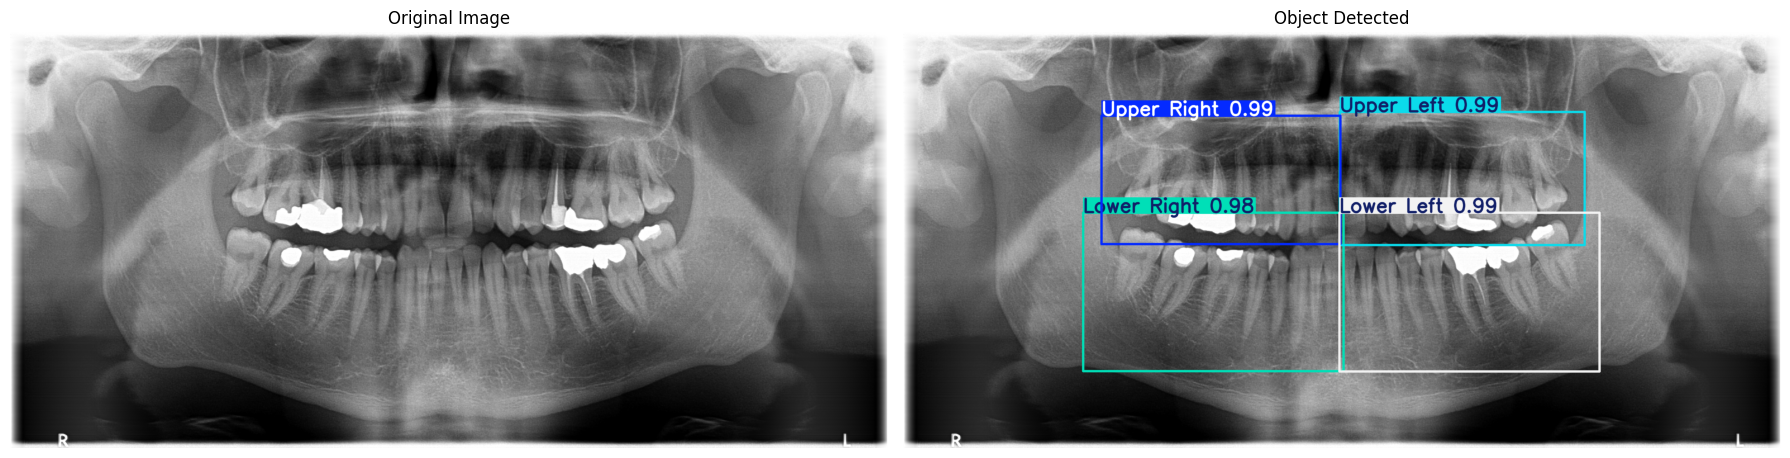

In [ ]:
smart_predict(quadrant_model_detection,quad_data_yaml['test'],save_crop_output_image=True,save_dir=os.path.join(stage1_config['paths']['runs_s1_output'],'Test Outputs Predictions'))


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_512.png: 384x768 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 75.2ms
Speed: 7.3ms preprocess, 75.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 768)
Class Name: Upper Right
Coordinates: [582.27734375, 248.68914794921875, 1371.7080078125, 676.1416625976562]
Confidence: %98.0
Class Name: Lower Right
Coordinates: [515.4501342773438, 559.4495849609375, 1348.3294677734375, 1087.950439453125]
Confidence: %98.0
Class Name: Upper Left
Coordinates: [1356.430419921875, 175.21043395996094, 2185.748779296875, 668.7935180664062]
Confidence: %97.0
Class Name: Lower Left
Coordinates: [1330.3450927734375, 538.5769653320312, 2163.968017578125, 1084.993408203125]
Confidence: %97.0


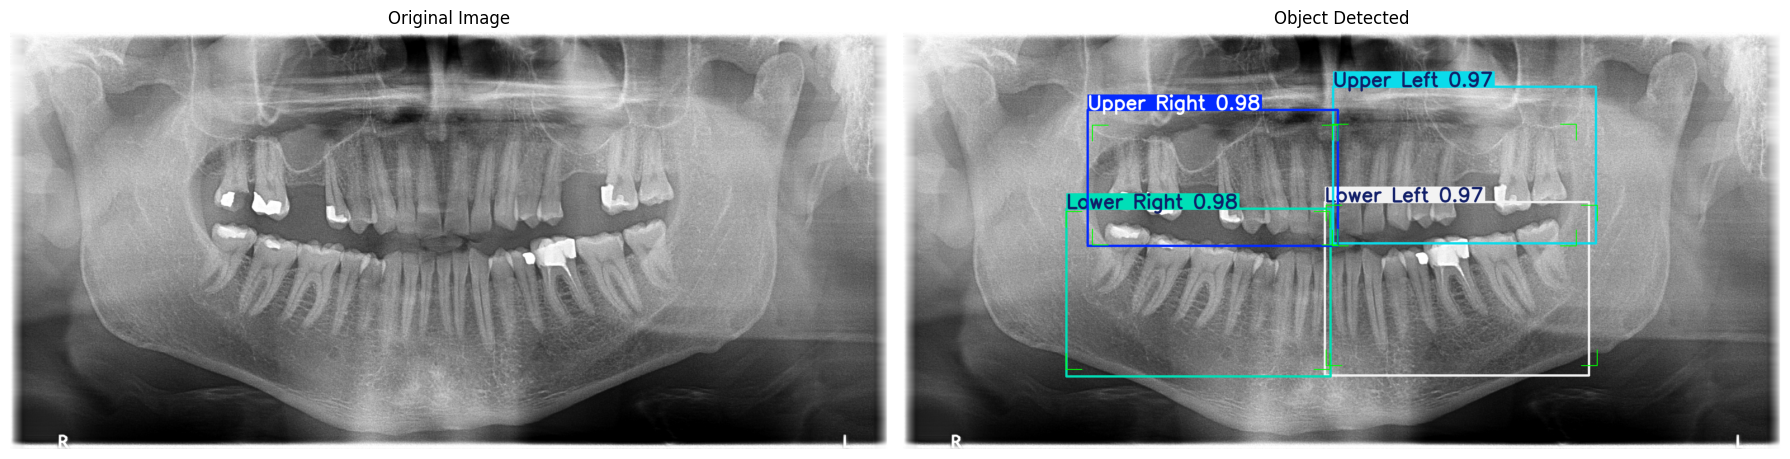

In [ ]:
smart_predict(quadrant_model_detection,quad_data_yaml['test'],show_true_boxes=True)


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_493.png: 480x1024 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 95.3ms
Speed: 7.9ms preprocess, 95.3ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 1024)
Class Name: Lower Right
Coordinates: [634.0875854492188, 574.842529296875, 1472.606201171875, 1079.396240234375]
Confidence: %99.0
Class Name: Lower Left
Coordinates: [1454.69921875, 603.5469360351562, 2256.822998046875, 1064.6751708984375]
Confidence: %99.0
Class Name: Upper Left
Coordinates: [1466.49853515625, 370.89208984375, 2166.14013671875, 759.9698486328125]
Confidence: %99.0
Class Name: Upper Right
Coordinates: [740.5459594726562, 350.83770751953125, 1471.6507568359375, 768.4490966796875]
Confidence: %99.0


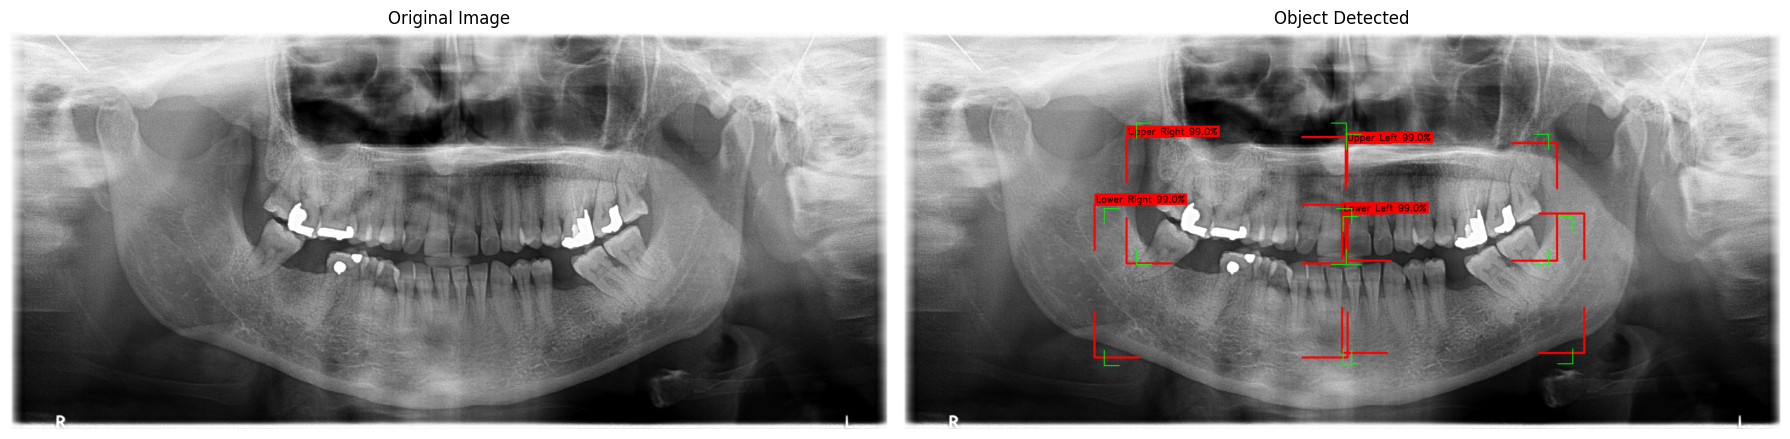

In [ ]:
smart_predict(quadrant_model_detection,quad_data_yaml['test'],show_true_boxes=True,apply_custom_draw_box=True)

In [ ]:
generate_report(stage1_config['paths']['runs_s1_output'], 
                os.path.join(stage1_config['paths']['runs_s1_output'], 'YOLO Training Report (Stage 1).pdf'),
                title='YOLO Training Report (Stage 1)')

Report saved to: ..\Runs\Stage 1\YOLO Training Report (Stage 1).pdf


In [ ]:
train_enum_df = pd.read_pickle(os.path.join(stage2_config['paths']['s2_main_path'], 'train_df (splitted).pkl'))
train_enum_df

,File_Name,Bbox,Height,Width,Enumeration,Quad
0,train_283.png,"[1283.3333333333333, 459.25925925925924, 100.0...",1316,2710,0,Upper Right
1,train_283.png,"[1200.0, 460.18518518518516, 90.74074074074065...",1316,2710,1,Upper Right
2,train_283.png,"[1100.9259259259259, 451.85185185185185, 119.4...",1316,2710,2,Upper Right
3,train_283.png,"[914.8148148148148, 466.66666666666663, 174.07...",1316,2710,4,Upper Right
4,train_283.png,"[822.2222222222222, 484.25925925925924, 182.40...",1316,2710,5,Upper Right
...,...,...,...,...,...,...
14352,train_370.png,"[1183.7142857142856, 864.4285714285713, 88.571...",1504,2872,3,Lower Right
14353,train_370.png,"[1063.7142857142856, 853.0, 134.28571428571422...",1504,2872,4,Lower Right
14354,train_370.png,"[846.5714285714284, 844.4285714285713, 260.0, ...",1504,2872,5,Lower Right
14355,train_370.png,"[752.2857142857142, 821.5714285714284, 237.142...",1504,2872,6,Lower Right


Cropping using trained quadrant model:   0%|          | 1/502 [00:00<03:28,  2.40it/s]

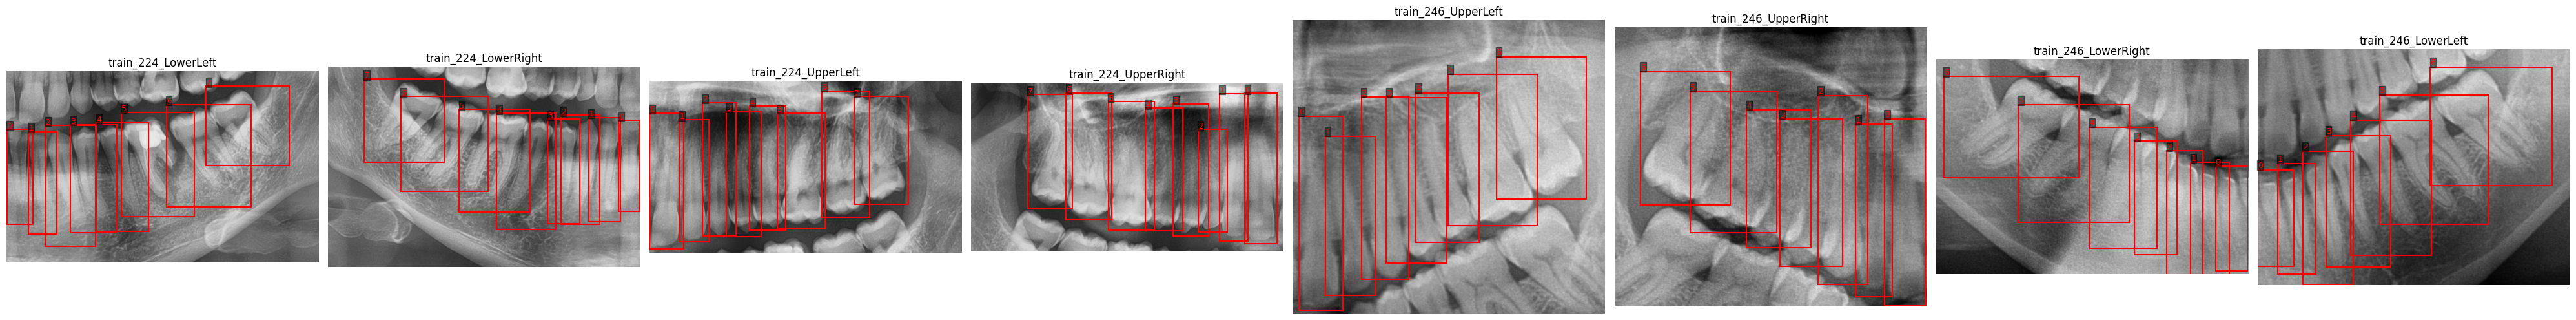

Cropping using trained quadrant model:   0%|          | 1/502 [00:01<12:38,  1.51s/it]


In [ ]:
export_enum_by_quad_using_model(quadrant_model_detection,
                                stage2_config['paths']['original_images_path'],
                                train_enum_df,os.path.join(stage2_config['paths']['s2_main_path'],'train'), debugging=True,debug_limit=8)

In [ ]:
export_enum_by_quad_using_model(quadrant_model_detection,
                                stage2_config['paths']['original_images_path'],
                                train_enum_df,os.path.join(stage2_config['paths']['s2_main_path'],'train'),conf_threshold=0.2)

Cropping using trained quadrant model:   3%|▎         | 13/502 [00:02<01:51,  4.38it/s]

FileExistsError: Error: File already exists at ..\Data\Processed\Stage 2 (Enumeration Detection)\train\images\train_176_LowerLeft.png.
Set clear_existing=True and re-run, or delete manually first.